In this notebook, we'll train a decision tree classifier on diabetes data and visualize the decision tree with graphviz

In [20]:
from sklearn import tree
import graphviz 
import os
import urllib.request

here we download the data from plotly

In [21]:
os.makedirs('data', exist_ok=True)
path = 'data/diabetes.csv'
if not os.path.exists(path):
    urllib.request.urlretrieve('https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv', path)
    print(f'Downloaded {path}')
else:
    print(f'{path} already exists')


data/diabetes.csv already exists


Next, we'll manually process the data from its comma separated value (csv) format

In [22]:
with open("data/diabetes.csv", "r") as f:
    data = f.readlines()
feats = data[0]
feats = feats.replace('\n','')
feats = feats.split(",")

Let's print the columns in the dataset

In [23]:
print(feats)

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


We now load the data into a list, `dat` and create a variable `labs` containing the label for a positive or negative example of diabetes

In [24]:
feats = feats[0:(len(feats)-1)]	
dat = []				
labs = []			
for i in range(1,len(data)):	
     line = data[i]		
     line = line.replace('\n','')		
     csvline = line.split(",")		
     labs = labs + [int(csvline[len(csvline)-1])]
     csvline = [float(csvline[i]) for i in range(len(csvline)-1)]
     dat = dat + [csvline]		

Let's find out how many examples we have

In [25]:
print(len(dat))

768


We can also examine an example row in the data, row 15

In [26]:
print(dat[15])

[7.0, 100.0, 0.0, 0.0, 0.0, 30.0, 0.484, 32.0]


Using scikit-learn, a machine learning library in Python, we'll train a decision tree 3 decision rules and fit it to our data and labels

In [27]:

clf = tree.DecisionTreeClassifier(max_leaf_nodes = 3)	
clf = clf.fit(dat, labs)			

We can calculate the accuracy of this model

In [28]:
correct = 0						
for i in range(len(dat)):	
    if clf.predict([dat[i]]) == labs[i]: correct = correct + 1
100.0* correct / len(dat)

77.21354166666667

Finally, we'll visualze our decision tree

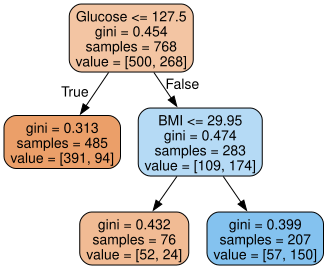

In [29]:
dot_data = tree.export_graphviz(clf, feature_names=feats,
                      filled=True, rounded=True) 
graph = graphviz.Source(dot_data)	
graph	